In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
# Pulizia csv da index e label
dataframe = pd.read_csv('../assets/seeds_29/train_29.csv', index_col=0)

dataframe = dataframe.drop(columns=['label'])

In [ ]:
#dataframe = pd.read_csv('../assets/seeds_29/train_29.csv') deprecata, si prende sia label che indice csv
dataframe.head()
dataframe.info()
dataframe.describe()

<class 'pandas.DataFrame'>
RangeIndex: 87447 entries, 0 to 87446
Columns: 514 entries, Unnamed: 0 to label
dtypes: float64(512), int64(2)
memory usage: 342.9 MB


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,label
count,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,...,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000
mean,54625.968026,0.679018,0.849446,0.445347,2.225511,0.402345,0.150700,0.787158,0.950749,1.445692,...,1.291831,0.069452,1.360384,0.855766,0.748231,0.792925,0.944384,1.011983,1.951677,1.678731
std,31556.659585,0.534371,0.468679,0.377176,0.651581,0.389670,0.247975,0.378525,0.582114,0.564774,...,0.647458,0.127874,0.750573,0.430739,0.545631,0.445133,0.754681,0.492185,0.822560,1.357813
min,0.000000,0.000000,0.000000,0.000000,0.066647,0.000000,0.000000,0.000000,0.000000,0.005960,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27319.500000,0.249905,0.493413,0.142307,1.773829,0.123257,0.001182,0.515294,0.516706,1.034520,...,0.807707,0.000864,0.817452,0.536997,0.333564,0.465984,0.356394,0.652256,1.370424,0.000000
50%,54665.000000,0.569472,0.816012,0.363509,2.216320,0.297176,0.040446,0.759877,0.884837,1.405674,...,1.232160,0.021013,1.253811,0.791904,0.647706,0.716649,0.768870,0.968252,1.940586,2.000000
75%,81891.500000,0.995952,1.155360,0.660914,2.654715,0.559709,0.189876,1.020424,1.302997,1.811699,...,1.714341,0.079874,1.773569,1.106637,1.045593,1.039662,1.354495,1.318304,2.509346,3.000000
max,109308.000000,4.143870,3.961852,3.237006,5.986111,4.305758,2.839259,3.651450,5.015615,4.156773,...,4.894304,2.531964,5.641622,3.502565,4.887534,3.861927,6.237524,4.545686,5.901646,3.000000


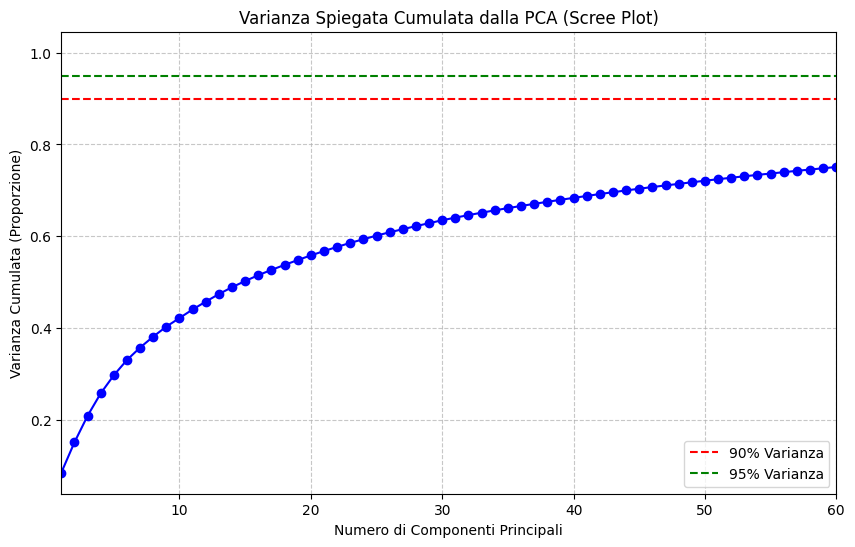

In [4]:
# 1. Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(dataframe)

# 2. Inizializza la PCA SENZA specificare il numero di componenti.
# In questo modo calcolerà tutte le 512 componenti (o min(n_samples, n_features)).
pca = PCA()
pca.fit(X_train_scaled)

# 3. Estrai la proporzione di varianza spiegata da ogni singola componente
# e calcola la somma cumulativa
varianza_singola = pca.explained_variance_ratio_
varianza_cumulata = np.cumsum(varianza_singola)

# 4. Creazione del Grafico (Scree Plot)
plt.figure(figsize=(10, 6))

# Plotta la curva della varianza cumulata
plt.plot(range(1, len(varianza_cumulata) + 1), varianza_cumulata, marker='o', linestyle='-', color='b')
plt.xlim(1, 60)

# Aggiungi linee di riferimento (es. per il 90% e il 95% della varianza)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Varianza')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Varianza')

# Estetica del grafico
plt.title('Varianza Spiegata Cumulata dalla PCA (Scree Plot)')
plt.xlabel('Numero di Componenti Principali')
plt.ylabel('Varianza Cumulata (Proporzione)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

In [5]:
PCA_32 = PCA(n_components=32)
X_train_pca_32 = PCA_32.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 32 componenti: {PCA_32.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 32 componenti: 0.6459


In [6]:
PCA_16 = PCA(n_components=16)
X_train_pca_16 = PCA_16.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 16 componenti: {PCA_16.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 16 componenti: 0.5148


In [7]:
PCA_8 = PCA(n_components=8)
X_train_pca_8 = PCA_8.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 8 componenti: {PCA_8.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 8 componenti: 0.3808


In [8]:
PCA_4 = PCA(n_components=4)
X_train_pca_4 = PCA_4.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 4 componenti: {PCA_4.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 4 componenti: 0.2570
